# Map Region

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

In [2]:
bathy = xr.open_dataset('gebco_2025_bathy.nc')

In [3]:
brown_gradient = mcolors.LinearSegmentedColormap.from_list(
    "custom_browns", 
    ["#988C81", "#4C3823"]
)
#
colors_water = plt.cm.Blues_r(np.linspace(0, 1, 50))
colors_land = brown_gradient(np.linspace(0, 1, 5))
all_colors = np.vstack((colors_water, colors_land))
cmap_custom = mcolors.ListedColormap(all_colors, name='BathyTopo')
#
data_min = bathy.elevation.min()
data_max = bathy.elevation.max()
#
levels_water = np.linspace(-500, 0, 51)
levels_land = np.linspace(0, data_max, 6)
#
levels = np.concatenate((levels_water[:-1], levels_land))
#
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=len(all_colors))

In [4]:
just_water = bathy.where((bathy.elevation > -500) & (bathy.elevation <=0))
levels_water = np.linspace(-500,0,10)
#
clat = 49.195045
clon = -123.301956

Text(-126.05871327264397, 47.18, '50 km')

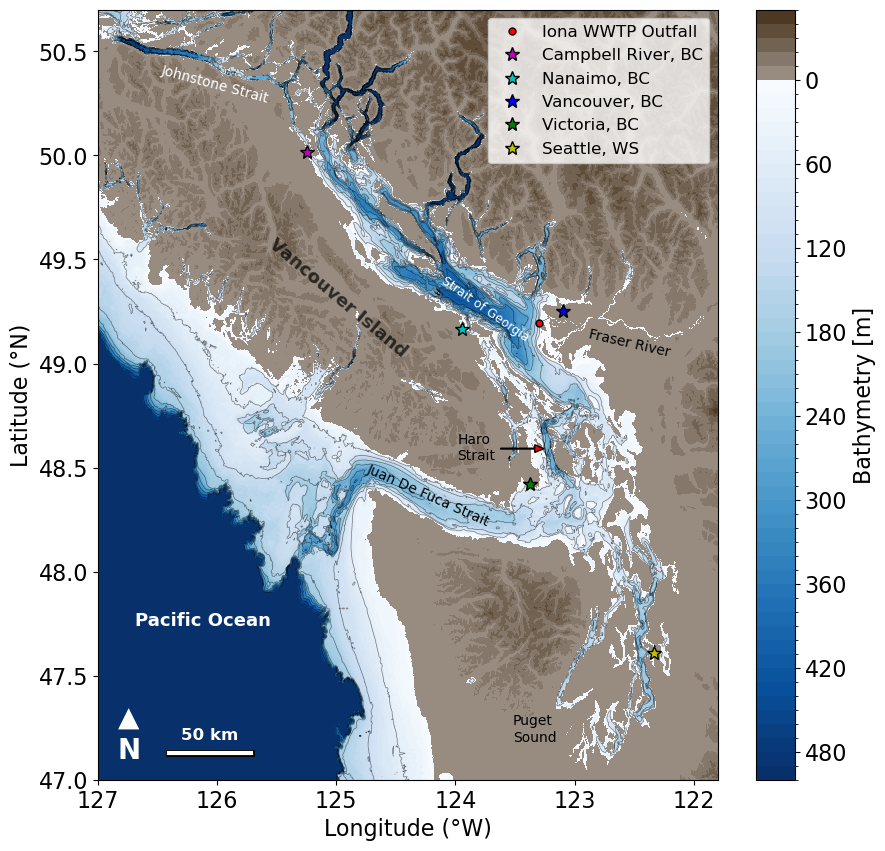

In [ ]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize = (10,10))
bathymetry = ax.pcolormesh(bathy.lon, bathy.lat, bathy.elevation, cmap=cmap_custom, norm=norm)
ax.contour(just_water.lon, just_water.lat, just_water.elevation, levels = levels_water, colors='black', alpha = .5
           ,linewidths=0.5, linestyles='solid')
ax.set_xlim(-127,-121.8); ax.set_ylim(47, 50.7) 
fmt_x = ticker.FuncFormatter(lambda x, pos: f'{abs(x):g}')
ax.xaxis.set_major_formatter(fmt_x)
ax.set_xlabel('Longitude (°W)');ax.set_ylabel('Latitude (°N)')
cbar = plt.colorbar(bathymetry, ax = ax)
fmt = ticker.FuncFormatter(lambda x, pos: f'{abs(x):.0f}')
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.set_label('Bathymetry [m]')
######################################################
ax.text(0.43, 0.33, 'Juan De Fuca Strait', rotation = -24, transform=ax.transAxes, fontsize = 10, zorder=3)
#ax.arrow(0.20, 0.30,  0.1,  0.070, head_width=0.01, fc='w', ec='b', transform=ax.transAxes, zorder=3)
#
ax.text(0.1, 0.88, 'Johnstone Strait', rotation = -15, transform=ax.transAxes, fontsize = 10, zorder=3, color = 'white')
#
#
ax.plot(clon, clat, 'ko', markersize=5, markerfacecolor='r', zorder=3, label = 'Iona WWTP Outfall')
#
ax.plot(-125.24459, 50.01634, 'k*', markersize=10, markerfacecolor='m', zorder=3, label = 'Campbell River, BC')
ax.plot(-123.94003, 49.16638, 'k*', markersize=10, markerfacecolor='c', zorder=3, label = 'Nanaimo, BC')
ax.plot(-123.10, 49.25, 'k*', markersize=10, markerfacecolor='b', zorder=3, label = 'Vancouver, BC')
ax.plot(-123.37, 48.42, 'k*', markersize=10, markerfacecolor='g', zorder=3, label = 'Victoria, BC')
ax.plot(-122.33, 47.61, 'k*', markersize=10, markerfacecolor='y', zorder=3, label = 'Seattle, WS')
#
ax.text(0.79, 0.55, 'Fraser River', rotation = -13, transform=ax.transAxes, fontsize = 10, zorder=3)
#
# SoG
#
ax.text(0.55, 0.57, 'Strait of Georgia', rotation=-35, transform=ax.transAxes, fontsize = 9, zorder=3, color = 'white')
#
# PS
#
ax.text(0.67, 0.050, 'Puget\nSound', transform=ax.transAxes, fontsize = 10, zorder=3)
#
ax.text(0.06, 0.2, 'Pacific Ocean', transform=ax.transAxes, fontsize = 13, zorder=3, fontweight = 'bold', color = 'white')
#
ax.text(0.27, 0.55, 'Vancouver Island', rotation = -40, transform=ax.transAxes, fontsize = 13, zorder=3, fontweight = 'bold', alpha = .7)
#
ax.text(0.58, 0.415, 'Haro\nStrait', transform=ax.transAxes, fontsize = 10, zorder=3)
ax.arrow(0.65, 0.43,  0.055, 0.0, head_width=0.01, fc='r', ec='k', transform=ax.transAxes, zorder=3)
#
ax.legend(fontsize = 12)
####
####
arrow_x, arrow_y = 0.05, 0.02

ax.text(arrow_x, arrow_y, u'\u25B2\nN', ha='center', va='bottom', 
        transform=ax.transAxes, fontsize=20, fontweight='bold', color='white', zorder=10)


scale_bar_length_km = 50 

lat_center = np.mean(ax.get_ylim())
one_degree_lon_km = 111.32 * np.cos(np.deg2rad(lat_center))
scale_bar_length_deg = scale_bar_length_km / one_degree_lon_km

bar_x = -126.4  
bar_y = 47.13   

ax.plot([bar_x, bar_x + scale_bar_length_deg], [bar_y, bar_y], 
        color='white', linewidth=3, zorder=10) 
ax.plot([bar_x, bar_x + scale_bar_length_deg], [bar_y, bar_y], 
        color='black', linewidth=5, zorder=9) 

ax.text(bar_x + scale_bar_length_deg/2, bar_y + 0.05, f'{scale_bar_length_km} km', 
        ha='center', va='bottom', color='white', fontweight='bold', fontsize=12, zorder=10)
ax.text(bar_x + scale_bar_length_deg/2, bar_y + 0.05, f'{scale_bar_length_km} km', 
        ha='center', va='bottom', color='black', fontweight='bold', fontsize=12, zorder=9, alpha=0.5)